## 단순선형 회귀
예제: Salary_Data.csv
```txt
학습목표
- 단순선형 회귀 개념에 대해 말할 수 있다
- y = wx + b의 의미에 대해 설명할 수 있다
- scikit-learn으로 모델 학습 가능하다
- 나는 예측값을 계산할 수 있다.

독립변수: 연차.. 그래프 그릴듯
종속변수: 연봉??
연차: x축
연봉: y축

1. 데이터 구조
총 30행
컬럼 2개( 연차, 연봉 )

2. 질문
경력이 늘어나면 연봉이 얼마나 증가하는가?
x = 경력, 독립변수( Feature )
y = 연봉, 종속변수( Label: 정답 )

3. 1차 방적식
- 변수가 2개
- 변수 X( 연차 )가 주어졌을 때 변수 y가 얼마일까 를 예측해 보자
- 연차가 올라가면 연봉도 올라간다.

4. 시각화 가능
산점도 + 직선 -> 개념이 보인다
질문
- 점들이 직선처럼 보이나요?
- 선형관계인가요? ( 연봉이 적어지지는 않을 듯 )

5. 방정식에 대해서
입력변수가 1개인 회귀모델: Salary = w x YearsExperience + b
w -> 기울기: 연차가 1년 증가시 연봉 증가량
b -> y절편: 연차 0일때 연봉값
```

STEP#1 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

STEP#2 데이터 불러오기

In [2]:
df = pd.read_csv("../../data/Salary_Data.csv")
df

# plt.plot(array, 'x')    # x축의 라벨이다.
# plt.show()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


STEP#3 기술통계

In [4]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


STEP#4 Feature( 독립변수-입력값 )와 Label( 종속변수 - 정답 )

In [5]:
# 슬라이싱과 인덱싱
# 앞에 콜론은 행이고, 뒤에 콜론은 열이다.
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].to_numpy()
X

array([[ 1.1],
       [ 1.3],
       [ 1.5],
       [ 2. ],
       [ 2.2],
       [ 2.9],
       [ 3. ],
       [ 3.2],
       [ 3.2],
       [ 3.7],
       [ 3.9],
       [ 4. ],
       [ 4. ],
       [ 4.1],
       [ 4.5],
       [ 4.9],
       [ 5.1],
       [ 5.3],
       [ 5.9],
       [ 6. ],
       [ 6.8],
       [ 7.1],
       [ 7.9],
       [ 8.2],
       [ 8.7],
       [ 9. ],
       [ 9.5],
       [ 9.6],
       [10.3],
       [10.5]])

In [6]:
y

array([ 39343.,  46205.,  37731.,  43525.,  39891.,  56642.,  60150.,
        54445.,  64445.,  57189.,  63218.,  55794.,  56957.,  57081.,
        61111.,  67938.,  66029.,  83088.,  81363.,  93940.,  91738.,
        98273., 101302., 113812., 109431., 105582., 116969., 112635.,
       122391., 121872.])

STEP#5 훈련 데이터와 데스트 데이터 분리하기

In [7]:
# 타이타닉은 훈련데이터와 테스트 데어터가 파일로 분리되어 있음.
# 훈련데이터와 데스트 데이터 분리한다. - 데이터 전처리
# 여기서 말하는 훈련이란 가중치 w( 기울기 )와 y절편의 b의 최적인 해를 구하기 위한 반복 훈련을 말함
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print(f'X_train : {X_train}, X_test : {X_test}, y_train : {y_train}, y_test : {y_test}')

X_train : [[ 9.6]
 [ 4. ]
 [ 5.3]
 [ 7.9]
 [ 2.9]
 [ 5.1]
 [ 3.2]
 [ 4.5]
 [ 8.2]
 [ 6.8]
 [ 1.3]
 [10.5]
 [ 3. ]
 [ 2.2]
 [ 5.9]
 [ 6. ]
 [ 3.7]
 [ 3.2]
 [ 9. ]
 [ 2. ]
 [ 1.1]
 [ 7.1]
 [ 4.9]
 [ 4. ]], X_test : [[ 1.5]
 [10.3]
 [ 4.1]
 [ 3.9]
 [ 9.5]
 [ 8.7]], y_train : [112635.  55794.  83088. 101302.  56642.  66029.  64445.  61111. 113812.
  91738.  46205. 121872.  60150.  39891.  81363.  93940.  57189.  54445.
 105582.  43525.  39343.  98273.  67938.  56957.], y_test : [ 37731. 122391.  57081.  63218. 116969. 109431.]


In [8]:
from sklearn.linear_model import LinearRegression
# lr은 이미 학습이 완료된 선형회귀 모델을 의미함
# 내부적 으로 1차 방정식임 -> y = wx + b
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
# X_test에 있는 각 경력값을 1차 방적식에 대입해서 예측 연봉을 계산하기
y_pred = lr.predict(X_test)
print(y_pred)

[ 40748.96184072 122699.62295594  64961.65717022  63099.14214487
 115249.56285456 107799.50275317]


산포도를 출력하시오

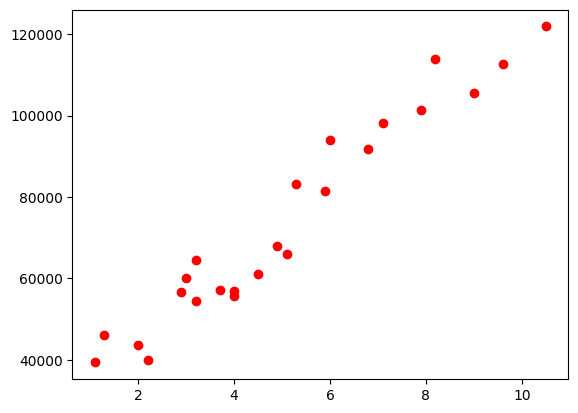

In [10]:
plt.scatter(X_train, y_train, color='red')

최소 제곱법을 활용한 직선 그리기

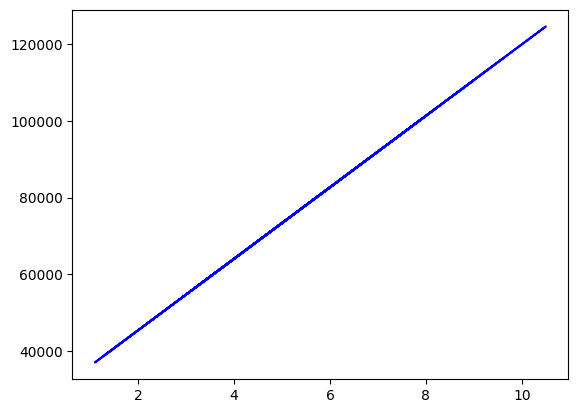

In [14]:
plt.plot(X_train, lr.predict(X_train), color='blue')

In [19]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import rc
path = "../../malgun.ttf"
font_name = fm.FontProperties(fname=path).get_name()
matplotlib.rc('font', family=font_name)
plt.rc('font', family="Malgun Gothic")

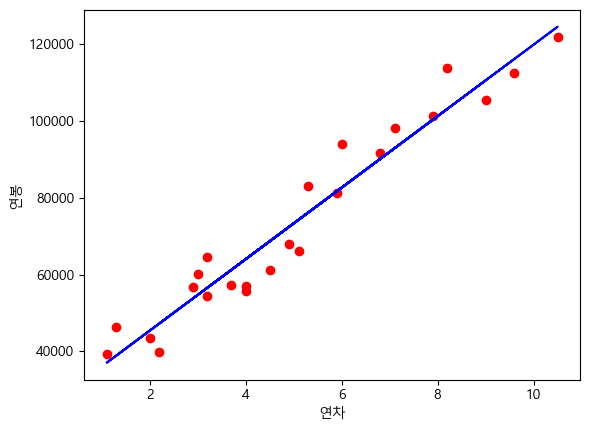

In [20]:
plt.scatter(X_train, y_train, color='red')  # X_train = 독립변수
plt.plot(X_train, lr.predict(X_train), color='blue')
plt.xlabel('연차')
plt.ylabel('연봉')
plt.show()